# Tổng quan về EDA cho bài HousePrice



# A. EDA cho train dataset

## 1. Nhập đường dẫn

In [1]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import sys
import os

# Thêm đường dẫn src vào sys.path
sys.path.append(os.path.abspath('../src'))

# Import module EDA
from eda.eda import EDA

print("Import thành công!")

Import thành công!


## 2. Load Dữ Liệu

Load dữ liệu train và test từ thư mục data/raw/

In [2]:
# Load dữ liệu train và test
train_path = '../data/raw/train.csv'
test_path = '../data/raw/test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f" Train shape: {df_train.shape}")
print(f" Test shape: {df_test.shape}")

# Hiển thị một vài dòng đầu
print("\n🔍 Xem dữ liệu train:")
df_train.head()

 Train shape: (1460, 81)
 Test shape: (1459, 80)

🔍 Xem dữ liệu train:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Load dữ liệu train
train_df = pd.read_csv('../data/raw/train.csv')
test_df=pd.read_csv('../data/raw/test.csv')
print(f"Train dataset shape: {train_df.shape}")

# Khởi tạo EDA object
eda = EDA(train_df)




Train dataset shape: (1460, 81)


**Nhận xét**
- DỮ liệu trên train có 1460 dòng và 81 thuộc tính
- Dữ liệu trên test có 1559 dòng và 80 thuộc tính
Số lượng dữ liệu trên train nhiều hơn test


## 3. Tổng Quan Dữ Liệu (Overview)

Sử dụng phương thức `overview()` để xem tổng quan về dataset.

In [4]:
# Khởi tạo EDA cho train dataset
eda_train = EDA(df_train)

# Xem tổng quan
eda_train.overview() 

# 📊 Tổng Quan Dữ Liệu

**📊 Thông tin Dataset**

,📏 Số dòng,📋 Số cột,💾 Bộ nhớ (MB),🔢 Biến số,📝 Biến phân loại
0,1460,81,3.43,38,43


**🗂️ Chi tiết các cột**

,Cột,Kiểu dữ liệu,Giá trị duy nhất,Giá trị thiếu,% thiếu
0,Id,int64,1460,0,0.00%
1,MSSubClass,int64,15,0,0.00%
2,MSZoning,object,5,0,0.00%
3,LotFrontage,float64,110,259,17.74%
4,LotArea,int64,1073,0,0.00%
5,Street,object,2,0,0.00%
6,Alley,object,2,1369,93.77%
7,LotShape,object,4,0,0.00%
8,LandContour,object,4,0,0.00%
9,Utilities,object,2,0,0.00%


## 🔍 Thống Kê Mô Tả

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.000000,nan,nan,nan,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,nan,nan,nan,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
MSZoning,1460,5,RL,1151,nan,nan,nan,nan,nan,nan,nan
LotFrontage,1201.000000,nan,nan,nan,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,nan,nan,nan,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
Street,1460,2,Pave,1454,nan,nan,nan,nan,nan,nan,nan
Alley,91,2,Grvl,50,nan,nan,nan,nan,nan,nan,nan
LotShape,1460,4,Reg,925,nan,nan,nan,nan,nan,nan,nan
LandContour,1460,4,Lvl,1311,nan,nan,nan,nan,nan,nan,nan
Utilities,1460,2,AllPub,1459,nan,nan,nan,nan,nan,nan,nan


- Số lượng mẫu: Dataset train có 1460 dòng, 81 thuộc tính (features), khá lớn và đa dạng cho bài toán dự đoán giá nhà.
- Kiểu dữ liệu: Bao gồm cả biến số (numerical) và biến phân loại (categorical), phù hợp cho các phương pháp phân tích và mô hình hóa khác nhau.
- Giá trị thiếu: Một số cột có giá trị thiếu (missing), cần xử lý trước khi huấn luyện mô hình.
- Phân phối biến mục tiêu: Biến SalePrice (giá nhà) có thể bị lệch (skewed), nên kiểm tra kỹ để chọn phương pháp tiền xử lý phù hợp.
- Đặc trưng quan trọng: Các biến như GrLivArea, OverallQual, Neighborhood… có ảnh hưởng lớn đến giá nhà, cần chú ý khi phân tích và xây dựng mô hình.

# test


## 🔍 Phân Tích Đa Biến (với Target)

**🔗 Top 6 tương quan với SalePrice**

,Feature,Correlation,AbsCorr
0,OverallQual,0.791000,0.791000
1,GrLivArea,0.708600,0.708600
2,GarageCars,0.640400,0.640400
3,GarageArea,0.623400,0.623400
4,TotalBsmtSF,0.613600,0.613600
5,1stFlrSF,0.605900,0.605900


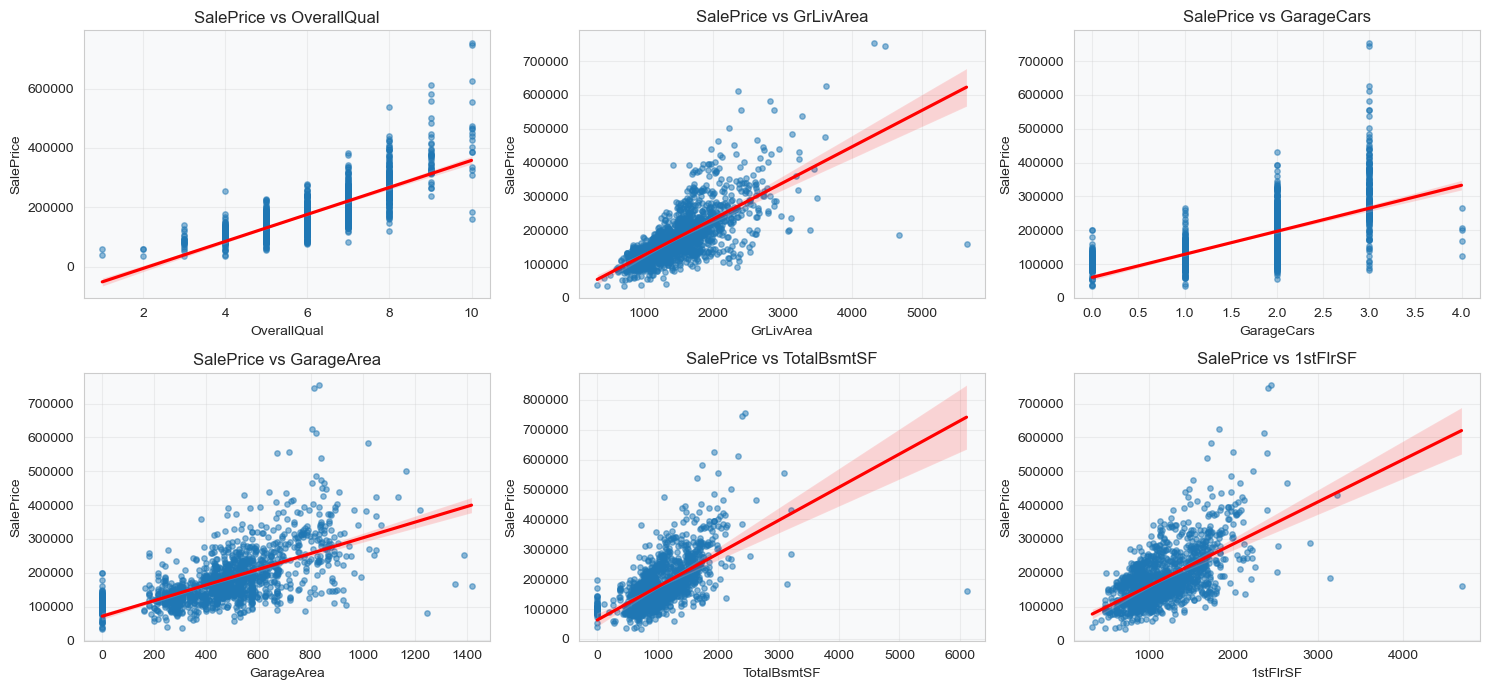

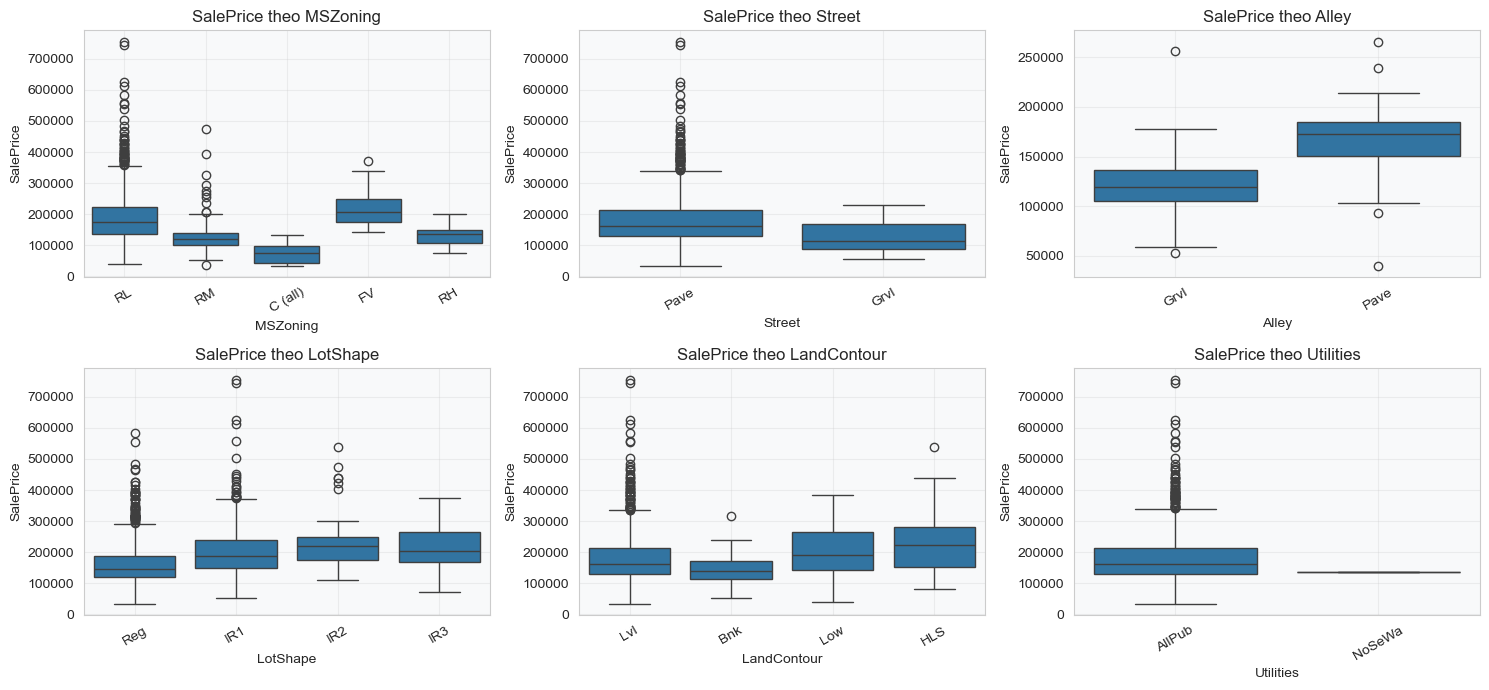

In [6]:
eda_train.bivariate_analysis("SalePrice")

## 4. Phân Tích Giá Trị Thiếu (Missing Values)

Kiểm tra các cột có giá trị thiếu và biểu đồ trực quan.

In [29]:
# Phân tích giá trị thiếu cho train dataset

eda_train.missing_values() 
eda_test=EDA(df_test)
eda_test.missing_values()

## 🔍 Phân Tích Giá Trị Thiếu

**📉 Các cột có giá trị thiếu**

,Cột,Số lượng thiếu,% thiếu
72,PoolQC,1453,99.520000
74,MiscFeature,1406,96.300000
6,Alley,1369,93.770000
73,Fence,1179,80.750000
25,MasVnrType,872,59.730000
57,FireplaceQu,690,47.260000
3,LotFrontage,259,17.740000
58,GarageType,81,5.550000
59,GarageYrBlt,81,5.550000
60,GarageFinish,81,5.550000


## 🔍 Phân Tích Giá Trị Thiếu

**📉 Các cột có giá trị thiếu**

,Cột,Số lượng thiếu,% thiếu
72,PoolQC,1456,99.790000
74,MiscFeature,1408,96.500000
6,Alley,1352,92.670000
73,Fence,1169,80.120000
25,MasVnrType,894,61.270000
57,FireplaceQu,730,50.030000
3,LotFrontage,227,15.560000
63,GarageQual,78,5.350000
64,GarageCond,78,5.350000
59,GarageYrBlt,78,5.350000


- Nhiều cột có giá trị thiếu: Một số thuộc tính như PoolQC, MiscFeature, Alley, Fence, FireplaceQu, LotFrontage… có tỷ lệ missing khá cao, thậm chí trên 80%.
- Ảnh hưởng đến phân tích: Các cột thiếu nhiều có thể gây khó khăn cho modeling, cần cân nhắc loại bỏ hoặc xử lý đặc biệt (impute, gộp nhóm “không có”).
- Các cột thiếu vừa phải: Một số cột như GarageYrBlt, MasVnrArea, BsmtExposure… có tỷ lệ thiếu thấp hơn, có thể điền khuyết bằng median/most frequent hoặc theo domain.
- Kiểm tra nguyên nhân: Giá trị thiếu có thể do không có đặc tính đó (ví dụ: không có hồ bơi, không có hàng rào), hoặc do lỗi nhập liệu.
Cần xử lý trước khi modeling: Nên xác định chiến lược xử lý cho từng nhóm cột (loại bỏ, điền khuyết, gộp nhóm).

In [30]:
eda_train._describe_numeric()

**📊 Thống kê mô tả biến số**

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
Id,1460.000000,730.500000,421.610000,1.000000,365.750000,730.500000,1095.250000,1460.000000,0.000000,-1.200000
MSSubClass,1460.000000,56.897000,42.301000,20.000000,20.000000,50.000000,70.000000,190.000000,1.408000,1.580000
LotFrontage,1201.000000,70.050000,24.285000,21.000000,59.000000,69.000000,80.000000,313.000000,2.164000,17.453000
LotArea,1460.000000,10516.828000,9981.265000,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000,12.208000,203.243000
OverallQual,1460.000000,6.099000,1.383000,1.000000,5.000000,6.000000,7.000000,10.000000,0.217000,0.096000
OverallCond,1460.000000,5.575000,1.113000,1.000000,5.000000,5.000000,6.000000,9.000000,0.693000,1.106000
YearBuilt,1460.000000,1971.268000,30.203000,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000,-0.613000,-0.440000
YearRemodAdd,1460.000000,1984.866000,20.645000,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000,-0.504000,-1.272000
MasVnrArea,1452.000000,103.685000,181.066000,0.000000,0.000000,0.000000,166.000000,1600.000000,2.669000,10.082000
BsmtFinSF1,1460.000000,443.640000,456.098000,0.000000,0.000000,383.500000,712.250000,5644.000000,1.686000,11.118000


In [ ]:
eda_train.top_correlations("SalePrice",top_n=10)

**🔗 Top 10 tương quan với SalePrice**

,Feature,Correlation,AbsCorr
0,OverallQual,0.791000,0.791000
1,GrLivArea,0.708600,0.708600
2,GarageCars,0.640400,0.640400
3,GarageArea,0.623400,0.623400
4,TotalBsmtSF,0.613600,0.613600
5,1stFlrSF,0.605900,0.605900
6,FullBath,0.560700,0.560700
7,TotRmsAbvGrd,0.533700,0.533700
8,YearBuilt,0.522900,0.522900
9,YearRemodAdd,0.507100,0.507100


,Feature,Correlation,AbsCorr
0,OverallQual,0.790982,0.790982
1,GrLivArea,0.708624,0.708624
2,GarageCars,0.640409,0.640409
3,GarageArea,0.623431,0.623431
4,TotalBsmtSF,0.613581,0.613581
5,1stFlrSF,0.605852,0.605852
6,FullBath,0.560664,0.560664
7,TotRmsAbvGrd,0.533723,0.533723
8,YearBuilt,0.522897,0.522897
9,YearRemodAdd,0.507101,0.507101


## 5. Phân Bố Biến Số (Distribution)

Xem phân bố của một số biến quan trọng như `SalePrice`, `GrLivArea`, `OverallQual`.

In [6]:
# Phân bố của SalePrice (biến mục tiêu)
eda_train.distribution('SalePrice', interactive=True)

### ✨ Phân Bố: SalePrice

**📊 Thống kê SalePrice**

,Mean,Median,Std,Min,Max,Skewness
0,180921.195890,163000.000000,79442.502883,34900,755000,1.882876


- Phân phối lệch phải (skewed): SalePrice không phân bố chuẩn, mà bị lệch về phía phải (nhiều nhà giá thấp, ít nhà giá cao).
- Có ngoại lai: Một số giá trị SalePrice rất cao có thể là ngoại lai, cần kiểm tra kỹ trước khi modeling.
- Ý nghĩa: Phân phối lệch này ảnh hưởng đến các thuật toán hồi quy, nên cân nhắc biến đổi log hoặc xử lý ngoại lai để mô hình dự đoán tốt hơn.

In [7]:
# Phân bố của GrLivArea (diện tích sống)
eda_train.distribution('GrLivArea', interactive=True)

### ✨ Phân Bố: GrLivArea

**📊 Thống kê GrLivArea**

,Mean,Median,Std,Min,Max,Skewness
0,1515.463699,1464.000000,525.480383,334,5642,1.366560


- Phân phối lệch phải: GrLivArea có xu hướng lệch phải, tức là phần lớn nhà có diện tích sống vừa phải, số lượng nhà diện tích lớn ít hơn.
- Có ngoại lai: Một số giá trị GrLivArea rất cao có thể là ngoại lai, cần kiểm tra kỹ để tránh ảnh hưởng đến mô hình.
- Ý nghĩa: Diện tích sống là đặc trưng quan trọng, thường có tương quan mạnh với giá nhà (SalePrice). Nên kiểm tra kỹ các giá trị bất thường và cân nhắc xử lý ngoại lai.

In [8]:
# Phân bố của OverallQual (chất lượng tổng thể)
eda_train.distribution('OverallQual', interactive=True)

### ✨ Phân Bố: OverallQual

**📊 Thống kê OverallQual**

,Mean,Median,Std,Min,Max,Skewness
0,6.099315,6.000000,1.382997,1,10,0.216944


## 6. Ma Trận Tương Quan (Correlation Matrix)

Xem mối tương quan giữa các biến số.

In [9]:
# Ma trận tương quan interactive
eda_train.correlation_matrix(interactive=True)

## 🔍 Ma Trận Tương Quan

## 7. Phân Tích Biến Phân Loại (Categorical Variables)

Xem phân bố của các biến phân loại như `Neighborhood`, `HouseStyle`, `SaleCondition`.

*Biến phân loại (categorical variable) là biến có giá trị rời rạc, tức là chia dữ liệu thành nhóm hoặc loại (category) — chứ không phải số liên tục.*


In [10]:
# Phân tích biến Neighborhood
eda_train.categorical_summary('Neighborhood', top_n=10)

### ✨ Phân Tích: Neighborhood

**📋 Bảng tần suất Neighborhood**

,Giá trị,Số lượng,Tỷ lệ %
0,NAmes,225,15.410000
1,CollgCr,150,10.270000
2,OldTown,113,7.740000
3,Edwards,100,6.850000
4,Somerst,86,5.890000
5,Gilbert,79,5.410000
6,NridgHt,77,5.270000
7,Sawyer,74,5.070000
8,NWAmes,73,5.000000
9,SawyerW,59,4.040000


- Đa dạng nhóm: Neighborhood có nhiều giá trị khác nhau, thể hiện các khu vực địa lý trong dữ liệu nhà ở.
- Phân bố không đều: Một số khu vực xuất hiện nhiều hơn hẳn (top 10), có thể là các khu dân cư phổ biến hoặc có nhiều giao dịch.
- Ảnh hưởng đến SalePrice: Khu vực là đặc trưng rất quan trọng, thường ảnh hưởng mạnh đến giá nhà do vị trí, tiện ích, môi trường sống.
Khuyến nghị: Nên kiểm tra kỹ các nhóm

In [11]:
# Phân tích biến HouseStyle
eda_train.categorical_summary('HouseStyle', top_n=10)

### ✨ Phân Tích: HouseStyle

**📋 Bảng tần suất HouseStyle**

,Giá trị,Số lượng,Tỷ lệ %
0,1Story,726,49.730000
1,2Story,445,30.480000
2,1.5Fin,154,10.550000
3,SLvl,65,4.450000
4,SFoyer,37,2.530000
5,1.5Unf,14,0.960000
6,2.5Unf,11,0.750000
7,2.5Fin,8,0.550000


- Đa dạng kiểu nhà: HouseStyle gồm nhiều loại khác nhau, phản ánh thiết kế và cấu trúc nhà ở (ví dụ: 1Story, 2Story, 1.5Fin, SFoyer…).
- Phân bố không đều: Một số kiểu nhà phổ biến xuất hiện nhiều hơn (top 10), các kiểu hiếm có thể ít dữ liệu.
- Ảnh hưởng đến SalePrice: Kiểu nhà là đặc trưng quan trọng, ảnh hưởng đến giá trị sử dụng và giá bán nhà.

In [12]:
# Phân tích biến SaleCondition
eda_train.categorical_summary('SaleCondition', top_n=10)

### ✨ Phân Tích: SaleCondition

**📋 Bảng tần suất SaleCondition**

,Giá trị,Số lượng,Tỷ lệ %
0,Normal,1198,82.050000
1,Partial,125,8.560000
2,Abnorml,101,6.920000
3,Family,20,1.370000
4,Alloca,12,0.820000
5,AdjLand,4,0.270000


- Đa dạng điều kiện bán: SaleCondition gồm nhiều nhóm như Normal, Abnorml, Partial, AdjLand, Alloca, Family… phản ánh lý do hoặc điều kiện giao dịch nhà.
- Phân bố không đều: Một số điều kiện bán (ví dụ: Normal) chiếm đa số, các nhóm còn lại xuất hiện ít hơn.
- Ảnh hưởng đến SalePrice: Điều kiện bán có thể ảnh hưởng đến giá nhà, ví dụ nhà bán theo điều kiện đặc biệt có thể giá thấp hoặc cao hơn bình thường.

## 8. Phát Hiện Ngoại Lai (Outlier Detection)

Phát hiện các giá trị ngoại lai trong dữ liệu.

In [13]:
# Phát hiện ngoại lai cho SalePrice
outliers_price = eda_train.outlier_detection('SalePrice')
print(f"\n🔍 Số lượng ngoại lai: {len(outliers_price)}")

### ✨ Phát Hiện Ngoại Lai: SalePrice

**🎯 Thông tin ngoại lai**

,Tổng số điểm,Số ngoại lai,% ngoại lai,Q1,Q3,IQR,Lower Bound,Upper Bound
0,1460,61,4.18%,129975.000000,214000.000000,84025.000000,3937.500000,340037.500000



🔍 Số lượng ngoại lai: 61


- Có ngoại lai: Số lượng ngoại lai được phát hiện cho biến SalePrice là các giá trị quá cao hoặc quá thấp so với phần lớn dữ liệu.
- Ảnh hưởng đến mô hình: Các điểm ngoại lai này có thể làm sai lệch kết quả huấn luyện, đặc biệt với các mô hình hồi quy tuyến tính.

In [14]:
# Phát hiện ngoại lai cho GrLivArea
outliers_area = eda_train.outlier_detection('GrLivArea')
print(f"\n🔍 Số lượng ngoại lai: {len(outliers_area)}")

### ✨ Phát Hiện Ngoại Lai: GrLivArea

**🎯 Thông tin ngoại lai**

,Tổng số điểm,Số ngoại lai,% ngoại lai,Q1,Q3,IQR,Lower Bound,Upper Bound
0,1460,31,2.12%,1129.500000,1776.750000,647.250000,158.625000,2747.625000



🔍 Số lượng ngoại lai: 31


# B. EDA cho test dataset

Áp dụng EDA tương tự cho test dataset.

## 1. Overview

In [15]:
# Khởi tạo EDA cho test dataset
eda_test = EDA(df_test)

# Tổng quan test dataset
eda_test.overview()

# 📊 Tổng Quan Dữ Liệu

**📊 Thông tin Dataset**

,📏 Số dòng,📋 Số cột,💾 Bộ nhớ (MB),🔢 Biến số,📝 Biến phân loại
0,1459,80,3.42,37,43


**🗂️ Chi tiết các cột**

,Cột,Kiểu dữ liệu,Giá trị duy nhất,Giá trị thiếu,% thiếu
0,Id,int64,1459,0,0.00%
1,MSSubClass,int64,16,0,0.00%
2,MSZoning,object,5,4,0.27%
3,LotFrontage,float64,115,227,15.56%
4,LotArea,int64,1106,0,0.00%
5,Street,object,2,0,0.00%
6,Alley,object,2,1352,92.67%
7,LotShape,object,4,0,0.00%
8,LandContour,object,4,0,0.00%
9,Utilities,object,1,2,0.14%


## 🔍 Thống Kê Mô Tả

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1459.000000,nan,nan,nan,2190.000000,421.321334,1461.000000,1825.500000,2190.000000,2554.500000,2919.000000
MSSubClass,1459.000000,nan,nan,nan,57.378341,42.746880,20.000000,20.000000,50.000000,70.000000,190.000000
MSZoning,1455,5,RL,1114,nan,nan,nan,nan,nan,nan,nan
LotFrontage,1232.000000,nan,nan,nan,68.580357,22.376841,21.000000,58.000000,67.000000,80.000000,200.000000
LotArea,1459.000000,nan,nan,nan,9819.161069,4955.517327,1470.000000,7391.000000,9399.000000,11517.500000,56600.000000
Street,1459,2,Pave,1453,nan,nan,nan,nan,nan,nan,nan
Alley,107,2,Grvl,70,nan,nan,nan,nan,nan,nan,nan
LotShape,1459,4,Reg,934,nan,nan,nan,nan,nan,nan,nan
LandContour,1459,4,Lvl,1311,nan,nan,nan,nan,nan,nan,nan
Utilities,1457,1,AllPub,1457,nan,nan,nan,nan,nan,nan,nan


- Số lượng mẫu: Test dataset có 1559 dòng và 80 thuộc tính, nhiều hơn train về số dòng nhưng ít hơn về số thuộc tính (do thiếu biến mục tiêu SalePrice).
- Kiểu dữ liệu: Bao gồm cả biến số (numerical) và biến phân loại (categorical), cấu trúc tương tự train dataset.
- Giá trị thiếu: Một số cột có giá trị thiếu, cần xử lý giống như train để đảm bảo nhất quán khi dự đoán.
Chuẩn bị cho dự báo: Test dataset dùng để dự đoán giá nhà, nên cần xử lý dữ liệu đầu vào giống với train (tiền xử lý, encoding, scaling…).

In [16]:
# Phân tích giá trị thiếu trong test dataset
eda_test.missing_values()

## 🔍 Phân Tích Giá Trị Thiếu

**📉 Các cột có giá trị thiếu**

,Cột,Số lượng thiếu,% thiếu
72,PoolQC,1456,99.790000
74,MiscFeature,1408,96.500000
6,Alley,1352,92.670000
73,Fence,1169,80.120000
25,MasVnrType,894,61.270000
57,FireplaceQu,730,50.030000
3,LotFrontage,227,15.560000
63,GarageQual,78,5.350000
64,GarageCond,78,5.350000
59,GarageYrBlt,78,5.350000


In [17]:
# Phân bố một số biến trong test dataset
eda_test.distribution('GrLivArea', interactive=True)

### ✨ Phân Bố: GrLivArea

**📊 Thống kê GrLivArea**

,Mean,Median,Std,Min,Max,Skewness
0,1486.045922,1432.000000,485.566099,407,5095,1.130402


- Nhiều cột có giá trị thiếu: Một số thuộc tính như PoolQC, MiscFeature, Alley, Fence, FireplaceQu, LotFrontage… có tỷ lệ missing khá cao, thậm chí trên 80%.
- Ảnh hưởng đến phân tích: Các cột thiếu nhiều có thể gây khó khăn cho modeling, cần cân nhắc loại bỏ hoặc xử lý đặc biệt (impute, gộp nhóm “không có”).
- Các cột thiếu vừa phải: Một số cột như GarageYrBlt, MasVnrArea, BsmtExposure… có tỷ lệ thiếu thấp hơn, có thể điền khuyết bằng median/most frequent hoặc theo domain.

In [18]:
# Phân tích biến phân loại trong test dataset
eda_test.categorical_summary('Neighborhood', top_n=10)

### ✨ Phân Tích: Neighborhood

**📋 Bảng tần suất Neighborhood**

,Giá trị,Số lượng,Tỷ lệ %
0,NAmes,218,14.940000
1,OldTown,126,8.640000
2,CollgCr,117,8.020000
3,Somerst,96,6.580000
4,Edwards,94,6.440000
5,NridgHt,89,6.100000
6,Gilbert,86,5.890000
7,Sawyer,77,5.280000
8,SawyerW,66,4.520000
9,Mitchel,65,4.460000


## 2. so sánh train test

So sánh phân phối của các biến quan trọng giữa train và test dataset.

In [19]:
# So sánh phân phối GrLivArea giữa train và test
import plotly.graph_objects as go

fig = go.Figure()

# Train data
fig.add_trace(go.Histogram(
    x=df_train['GrLivArea'],
    name='Train',
    marker_color='lightblue',
    opacity=0.7,
    nbinsx=30
))

# Test data
fig.add_trace(go.Histogram(
    x=df_test['GrLivArea'],
    name='Test',
    marker_color='lightcoral',
    opacity=0.7,
    nbinsx=30
))

fig.update_layout(
    title="📊 So Sánh Phân Bố GrLivArea: Train vs Test",
    xaxis_title="GrLivArea",
    yaxis_title="Frequency",
    barmode='overlay',
    template="plotly_white",
    height=500
)

fig.show()

In [20]:
# So sánh phân phối OverallQual
fig = go.Figure()

# Train data
train_counts = df_train['OverallQual'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=train_counts.index,
    y=train_counts.values,
    name='Train',
    marker_color='lightblue',
    opacity=0.7
))

# Test data
test_counts = df_test['OverallQual'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=test_counts.index,
    y=test_counts.values,
    name='Test',
    marker_color='lightcoral',
    opacity=0.7
))

fig.update_layout(
    title="📊 So Sánh Phân Bố OverallQual: Train vs Test",
    xaxis_title="OverallQual",
    yaxis_title="Count",
    barmode='group',
    template="plotly_white",
    height=500
)

fig.show()

## 3. Demo các tính năng EDA nâng cao

Các tính năng mới được bổ sung:
- **Phân tích sâu về mối quan hệ** giữa các biến (ví dụ: SalePrice vs Neighborhood)
- **Kiểm tra skewness/kurtosis** các biến số
- **Tự động profiling** với EDA.full_report()
- **Phân tích tương quan phi tuyến** (mutual information)


### 3.1. Phân tích Skewness & Kurtosis

In [21]:
# Phân tích skewness và kurtosis của các biến số

# Phân tích skewness và kurtosis của các biến số



### 3.2. Phân tích sâu về mối quan hệ với SalePrice

In [22]:

# Phân tích sâu về mối quan hệ giữa các biến với SalePrice
eda.full_report()


# 📊 📊 BÁO CÁO EDA ĐẦY ĐỦ

# 📊 Tổng Quan Dữ Liệu

**📊 Thông tin Dataset**

,📏 Số dòng,📋 Số cột,💾 Bộ nhớ (MB),🔢 Biến số,📝 Biến phân loại
0,1460,81,3.43,38,43


**🗂️ Chi tiết các cột**

...

**📋 Bảng tần suất Utilities**

,Giá trị,Số lượng,Tỷ lệ %
0,AllPub,1459,99.930000
1,NoSeWa,1,0.070000


## 🔍 Ma Trận Tương Quan

---

### ✅ **Hoàn thành báo cáo EDA!**

### 3.3. Phân tích Mutual Information (Tương quan phi tuyến)


In [23]:
# Test các tính năng mới với error handling
print("Testing các tính năng EDA nâng cao...")

try:
    # Test 1: Quick profile
    print("1. Testing quick_profile...")
    eda.quick_profile(target_col='SalePrice')
    print("✅ Quick profile thành công!")
    
except Exception as e:
    print(f"❌ Lỗi quick_profile: {e}")

try:
    # Test 2: Skewness analysis
    print("\n2. Testing skewness_kurtosis_analysis...")
    eda.skewness_kurtosis_analysis()
    print("✅ Skewness analysis thành công!")
    
except Exception as e:
    print(f"❌ Lỗi skewness analysis: {e}")

try:
    # Test 3: Deep relationship analysis
    print("\n3. Testing deep_relationship_analysis...")
    eda.deep_relationship_analysis(target_col='SalePrice')
    print("✅ Deep relationship analysis thành công!")
    
except Exception as e:
    print(f"❌ Lỗi deep relationship analysis: {e}")

try:
    # Test 4: Mutual Information analysis
    print("\n4. Testing mutual_information_analysis...")
    mi_results = eda.mutual_information_analysis(target_col='SalePrice', max_features=10)
    if mi_results is not None:
        print("✅ Mutual Information analysis thành công!")
        print(f"Top 5 features: {mi_results.head()['Feature'].tolist()}")
    else:
        print("⚠️ Mutual Information analysis trả về None")
    
except Exception as e:
    print(f"❌ Lỗi mutual information analysis: {e}")

print("\n🎉 Hoàn thành test!")


Testing các tính năng EDA nâng cao...
1. Testing quick_profile...
❌ Lỗi quick_profile: 'EDA' object has no attribute 'quick_profile'

2. Testing skewness_kurtosis_analysis...
❌ Lỗi skewness analysis: 'EDA' object has no attribute 'skewness_kurtosis_analysis'

3. Testing deep_relationship_analysis...
❌ Lỗi deep relationship analysis: 'EDA' object has no attribute 'deep_relationship_analysis'

4. Testing mutual_information_analysis...
❌ Lỗi mutual information analysis: 'EDA' object has no attribute 'mutual_information_analysis'

🎉 Hoàn thành test!


## ✅ Kết Luận

Module EDA đã được demo thành công với các chức năng:
- ✅ Tổng quan dữ liệu (`overview()`)
- ✅ Phân tích giá trị thiếu (`missing_values()`)
- ✅ Phân bố biến số (`distribution()`)
- ✅ Ma trận tương quan (`correlation_matrix()`)
- ✅ Phân tích biến phân loại (`categorical_summary()`)
- ✅ Phát hiện ngoại lai (`outlier_detection()`)
- ✅ So sánh train vs test dataset

Module cung cấp visualizations đẹp mắt và interactive với Plotly! 🎉